In [ ]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [ ]:
df = pd.read_csv('/content/BankChurn.csv')
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male,Exited
0,619,42,2,0.00,1,1,1,101348.88,0,0,0,1
1,608,41,1,83807.86,1,0,1,112542.58,0,1,0,0
2,502,42,8,159660.80,3,1,0,113931.57,0,0,0,1
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,1,0,0


In [ ]:
print(f'Dataset Shape: {df.shape}')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CreditScore        10000 non-null  int64  
 1   Age                10000 non-null  int64  
 2   Tenure             10000 non-null  int64  
 3   Balance            10000 non-null  float64
 4   NumOfProducts      10000 non-null  int64  
 5   HasCrCard          10000 non-null  int64  
 6   IsActiveMember     10000 non-null  int64  
 7   EstimatedSalary    10000 non-null  float64
 8   Geography_Germany  10000 non-null  int64  
 9   Geography_Spain    10000 non-null  int64  
 10  Gender_Male        10000 non-null  int64  
 11  Exited             10000 non-null  int64  
dtypes: float64(2), int64(10)
memory usage: 937.6 KB


In [ ]:
df.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.250900,0.247700,0.545700,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.433553,0.431698,0.497932,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,0.000000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,0.000000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,0.000000,1.000000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,1.000000,0.000000,1.000000,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000,1.000000,1.000000


In [ ]:
print(f'Missing value count: {df.isna().sum().sum()}')
print(f"Duplicate rows: {df.duplicated().sum()}")

Missing value count: 0
Duplicate rows: 0


In [ ]:
class_balance = df['Exited'].value_counts()

class_counts = pd.DataFrame({
    'Class': ["Stayed (0)", "Exited (1)"],
    'Count': class_balance.values
})
display(class_counts)

,Class,Count
0,Stayed (0),7963
1,Exited (1),2037


In [ ]:
X = df.drop(columns =['Exited'])
y = df['Exited']
print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

X shape: (10000, 11)
y shape: (10000,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Training feature shape:", X_train.shape)
print("Testing feature shape :", X_test.shape)
print("Training target shape :", y_train.shape)
print("Testing target shape  :", y_test.shape)

Training feature shape: (8000, 11)
Testing feature shape : (2000, 11)
Training target shape : (8000,)
Testing target shape  : (2000,)


In [ ]:

tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)
tree_pred = tree_model.predict(X_test)


In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

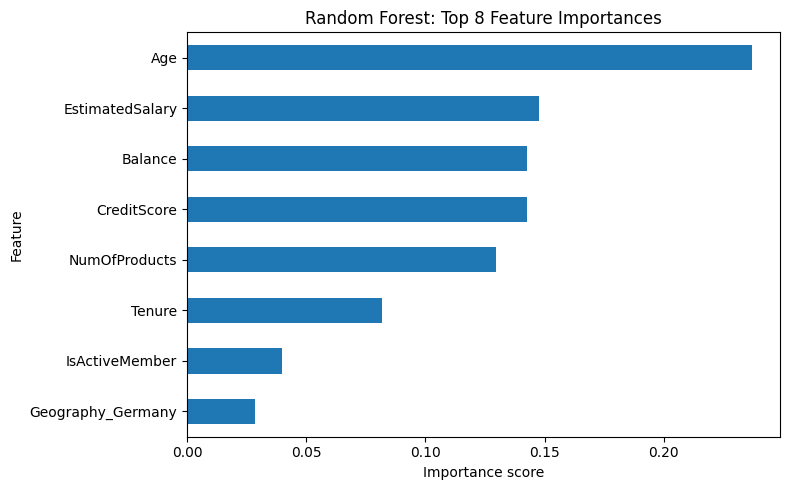

In [ ]:
rf_importance = (
    pd.Series(rf_model.feature_importances_, index=X.columns)
    .sort_values(ascending=False)
    .head(8)
)

plt.figure(figsize=(8, 5))
rf_importance.sort_values().plot(kind="barh")
plt.title("Random Forest: Top 8 Feature Importances")
plt.xlabel("Importance score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [ ]:
ada_model = AdaBoostClassifier(
    n_estimators=200,
    learning_rate=0.8,
    random_state=42,
)
ada_model.fit(X_train, y_train)
ada_pred = ada_model.predict(X_test)

In [ ]:
stack_estimators = [
    ("rf", RandomForestClassifier(n_estimators=150, random_state=42)),
    ("ada", AdaBoostClassifier(n_estimators=100, random_state=42)),
]

stack_model = StackingClassifier(
    estimators=stack_estimators,
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=5,
)

stack_model.fit(X_train, y_train)
stack_pred = stack_model.predict(X_test)


In [ ]:
acc= accuracy_score(y_test, stack_pred)
print(f'Accuracy: {acc}')

cm= confusion_matrix(y_test, stack_pred)
print(f'\nConfusion Matrix:\n{cm}')

print("\nClassification report:\n")
print(classification_report(y_test, stack_pred, target_names=["Benign", "Malignant"], digits=4))


Accuracy: 0.866

Confusion Matrix:
[[1532   61]
 [ 207  200]]

Classification report:

              precision    recall  f1-score   support

      Benign     0.8810    0.9617    0.9196      1593
   Malignant     0.7663    0.4914    0.5988       407

    accuracy                         0.8660      2000
   macro avg     0.8236    0.7266    0.7592      2000
weighted avg     0.8576    0.8660    0.8543      2000



In [ ]:
def eval_model(y_test, y_pred):
  acc = accuracy_score(y_test, y_pred)
  f_score = f1_score(y_test, y_pred)
  return acc,f_score

In [ ]:

tree_acc, tree_f1 = eval_model(y_test, tree_pred)
rf_acc, rf_f1 = eval_model(y_test, rf_pred)
ada_acc, ada_f1 = eval_model(y_test, ada_pred)
stack_acc, stack_f1 = eval_model(y_test, stack_pred)

results = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest", "AdaBoost", "Stacking"],
    "Test Accuracy": [tree_acc, rf_acc, ada_acc, stack_acc],
    "F1 Score": [tree_f1, rf_f1, ada_f1, stack_f1],
})

In [ ]:
print('Model Comparison')
display(results)

Model Comparison


,Model,Test Accuracy,F1 Score
0,Decision Tree,0.8515,0.536661
1,Random Forest,0.8630,0.577160
2,AdaBoost,0.8600,0.569231
3,Stacking,0.8660,0.598802


According to the model comparison table the best performing model is the stacking model with the highest accuracy and F1-score. Overall, ensemble methods can be used to reduce variance in prediction compared to a single tree model  and improve stability by combining several weak models into one classifier and making prediction based on the majority of votes made by the baseline models.